In [3]:
import torch
from transformers import TextStreamer
from llava.constants import IMAGE_TOKEN_INDEX, DEFAULT_IMAGE_TOKEN, DEFAULT_IM_START_TOKEN, DEFAULT_IM_END_TOKEN
from llava.conversation import conv_templates, SeparatorStyle
from llava.model.builder import load_pretrained_model
from llava.utils import disable_torch_init
from llava.mm_utils import process_images, tokenizer_image_token, get_model_name_from_path
from PIL import Image
import matplotlib.pyplot as plt

# ------------------------------------------------
# User settings
# ------------------------------------------------
model_path = "liuhaotian/llava-v1.5-7b"  # 7B model
device = "cuda"  ## ***with "cuda" it uses multiple gpu automatically if it detects , cuda:0 forces to use 1st gpu
temperature = 0.2
max_new_tokens = 512

# ------------------------------------------------
# Load model (no quantization, FP16)
# ------------------------------------------------
disable_torch_init()
model_name = get_model_name_from_path(model_path)

tokenizer, model, image_processor, context_len = load_pretrained_model(
    model_path=model_path,
    model_base=None,
    model_name=model_name,
    load_8bit=False,
    load_4bit=False,
    device=device
)

# ------------------------------------------------
# Pick conversation template
# ------------------------------------------------
if "llama-2" in model_name.lower():
    conv_mode = "llava_llama_2"
elif "mistral" in model_name.lower():
    conv_mode = "mistral_instruct"
elif "v1.6-34b" in model_name.lower():
    conv_mode = "chatml_direct"
elif "v1" in model_name.lower():
    conv_mode = "llava_v1"
elif "mpt" in model_name.lower():
    conv_mode = "mpt"
else:
    conv_mode = "llava_v0"

conv = conv_templates[conv_mode].copy()
roles = ('user', 'assistant') if "mpt" in model_name.lower() else conv.roles

# ------------------------------------------------
# Function to run LLaVA on an image and text query
# ------------------------------------------------
def chat_with_image_query(image_file: str, prompt: str):
    """Pass image path and user query, returns assistant response."""
    
    # Load and process image
    image = Image.open(image_file).convert("RGB")
    image_size = image.size
    image_tensor = process_images([image], image_processor, model.config)
    if isinstance(image_tensor, list):
        image_tensor = [im.to(model.device, dtype=torch.float16) for im in image_tensor]
    else:
        image_tensor = image_tensor.to(model.device, dtype=torch.float16)
    
    # Display image
    plt.imshow(image)
    plt.axis("off")
    plt.show()
    
    # Print user query
    print(f"\nUser: {prompt}\n")
    
    # Pick a new conversation object to avoid old messages
    conv_session = conv_templates[conv_mode].copy()
    roles_session = ('user', 'assistant') if "mpt" in model_name.lower() else conv_session.roles

    # Insert image token for first turn
    if model.config.mm_use_im_start_end:
        prompt_full = DEFAULT_IM_START_TOKEN + DEFAULT_IMAGE_TOKEN + DEFAULT_IM_END_TOKEN + "\n" + prompt
    else:
        prompt_full = DEFAULT_IMAGE_TOKEN + "\n" + prompt

    conv_session.append_message(conv_session.roles[0], prompt_full)
    conv_session.append_message(conv_session.roles[1], None)
    full_prompt = conv_session.get_prompt()

    input_ids = tokenizer_image_token(full_prompt, tokenizer, IMAGE_TOKEN_INDEX, return_tensors="pt").unsqueeze(0).to(model.device)
    streamer = TextStreamer(tokenizer, skip_prompt=True, skip_special_tokens=True)

    # Generate response
    with torch.inference_mode():
        output_ids = model.generate(
            input_ids,
            images=image_tensor,
            image_sizes=[image_size],
            do_sample=True if temperature > 0 else False,
            temperature=temperature,
            max_new_tokens=max_new_tokens,
            streamer=streamer,
            use_cache=True,
        )

    output_text = tokenizer.decode(output_ids[0], skip_special_tokens=True).strip()
    
    # Print assistant response
    print(f"Assistant: {output_text}\n")
    return output_text

# ------------------------------------------------
# Example usage
# ------------------------------------------------

##BTW in LLAVA we can keep our old converstion continnue for single image, just here im resetting it for each text query

You are using a model of type llava to instantiate a model of type llava_llama. This is not supported for all configurations of models and can yield errors.
Loading checkpoint shards: 100%|██████████| 2/2 [00:01<00:00,  1.33it/s]


### Object Tagging

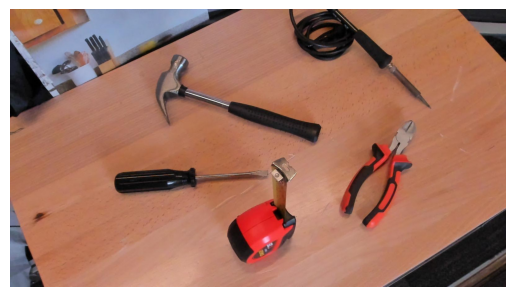


User: Describe each object in 2-3 words, with name of object and its single majority colour like white mug

1. Hammer - Black and silver
2. Wire cutter - Black
3. Screwdriver - Black and silver
4. Pliers - Black and silver
5. Screwdriver - Black and silver
6. Wire cutter - Black
7. Screwdriver - Black and silver
8. Pliers - Black and silver
9. Screwdriver - Black and silver
10. Wire cutter - Black
Assistant: 1. Hammer - Black and silver
2. Wire cutter - Black
3. Screwdriver - Black and silver
4. Pliers - Black and silver
5. Screwdriver - Black and silver
6. Wire cutter - Black
7. Screwdriver - Black and silver
8. Pliers - Black and silver
9. Screwdriver - Black and silver
10. Wire cutter - Black



In [4]:
image_path = "/scratch/codepk37/lerftogo/lerftogo/data/tools_take1/img61.jpg"
query_text = "Describe each object in 2-3 words, with name of object and its single majority colour like white mug"

response = chat_with_image_query(image_path, query_text)

### Task oriented query

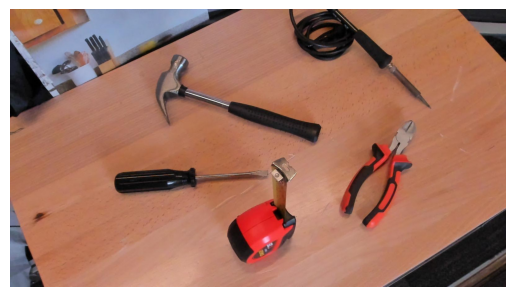


User: I'll give task based query based in it tell me name of object and its colour that can be used for it like 'black mug', Query: i wanted to check length of bedroom

The object is a tape measure, and it is red in color.
Assistant: The object is a tape measure, and it is red in color.



In [6]:

image_path = "/scratch/codepk37/lerftogo/lerftogo/data/tools_take1/img61.jpg"
query_text = "I'll give task based query based in it tell me name of object and its colour that can be used for it like 'black mug', Query: i wanted to check length of bedroom"

response = chat_with_image_query(image_path, query_text)